<a href="https://colab.research.google.com/github/Upendra6465/Upendra6465/blob/main/Gen_AI_BootCamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain langchain-experimental openai cohere tiktoken typing-extensions faiss-cpu textract

In [ ]:
!pip install langchain openai ai21 huggingface_hub mysql-connector-python langchain-experimental pandas matplotlib tiktoken transformers textract faiss-cpu

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 19.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.8/409.8 kB 26.9 MB/s eta 0:00:00
  Created wheel for ai21: filename=ai21-1.3.3-py3-none-any.whl size=26614 sha256=ca5f4ca3be4c7f5493c45ecfe83b13048b754825057dd88fb382ae8802593609
  Stored in directory: /root/.cache/pip/wheels/41/6e/17/8112137931083657822bdd6eb4309d5f9c0f5edf8c2622fa90
Successfully built ai21
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.14.0 requires protobuf<4.21,>=3.20.3, but you have protobuf 4.21.12 which is incompatible.


In [ ]:
from getpass import getpass
import os

#setup the api key
# os.environ["COHERE_API_KEY"] = getpass("Enter COhere API Key")
os.environ["OPENAI_API_KEY"] = getpass("Enter OpenAI Key")

# Q&A

## Use case

Chatbots are one of the central LLM use-cases. The core features of chatbots are that they can have long-running conversations and have access to information that users want to know about.

Aside from basic prompting and LLMs, memory and retrieval are the core components of a chatbot. Memory allows a chatbot to remember past interactions, and retrieval provides a chatbot with up-to-date, domain-specific information.

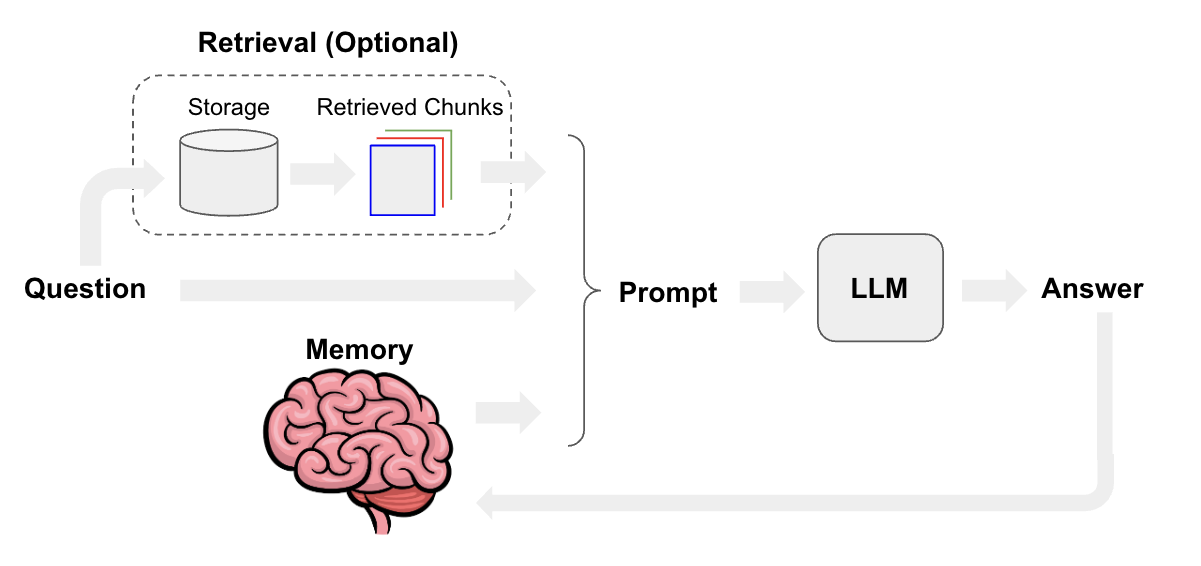

In [ ]:
from langchain.chat_models import ChatOpenAI
from langchain.llms import OpenAI
# from langchain.llms import Cohere
# from langchain.chat_models import ChatCohere
from langchain.schema import HumanMessage, SystemMessage

# chat = ChatOpenAI(model="gpt-3.5-turbo")
chat = ChatCohere()
chat(
    [
        HumanMessage(
            content="Translate this sentence from English to French: I love programming."
        )
    ]
)

AIMessage(content="J'adore la programmation.")

In [ ]:
messages = [
    SystemMessage(
        content="You are a helpful assistant that translates English to French."
    ),
    HumanMessage(content="I love programming."),
]
chat(messages)

AIMessage(content="J'adore programmer.")

In [ ]:
from langchain.chat_models import CohereChat

chat = CohereChat()

In [ ]:
from langchain.chains import ConversationChain

conversation = ConversationChain(llm=chat)
conversation.run("Translate this sentence from English to French: I love programming.")

'Je suis désolé, je ne peux pas traduire cette phrase en français.'

In [ ]:
conversation.run("Translate it to German.")

'Ich liebe das Programmieren.'

## Memory

As we mentioned above, the core component of chatbots is the memory system. One of the simplest and most commonly used forms of memory is `ConversationBufferMemory`:

* This memory allows for storing of messages in a `buffer`
* When called in a chain, it returns all of the messages it has stored

LangChain comes with many other types of memory, too. [See here](/docs/modules/memory/) for in-depth documentation on memory types.

For now let's take a quick look at ConversationBufferMemory. We can manually add a few chat messages to the memory like so:

In [ ]:
from langchain.memory import ConversationBufferMemory

memory = ConversationBufferMemory()
memory.chat_memory.add_user_message("hi!")
memory.chat_memory.add_ai_message("whats up?")

And now we can load from our memory. The key method exposed by all `Memory` classes is `load_memory_variables`. This takes in any initial chain input and returns a list of memory variables which are added to the chain input.

Since this simple memory type doesn't actually take into account the chain input when loading memory, we can pass in an empty input for now:

In [ ]:
memory.load_memory_variables({})

{'history': 'Human: hi!\nAI: whats up?'}

We can also keep a sliding window of the most recent `k` interactions using `ConversationBufferWindowMemory`.

In [ ]:
from langchain.memory import ConversationBufferWindowMemory

memory = ConversationBufferWindowMemory(k=2)
memory.save_context({"input": "hi"}, {"output": "whats up"})
memory.save_context({"input": "not much you"}, {"output": "not much"})
memory.load_memory_variables({})

{'history': 'Human: hi\nAI: whats up\nHuman: not much you\nAI: not much'}

`ConversationSummaryMemory` is an extension of this theme.

It creates a summary of the conversation over time.

This memory is most useful for longer conversations where the full message history would consume many tokens.

In [ ]:
from langchain.llms import OpenAI
from langchain.memory import ConversationSummaryMemory

llm = OpenAI(temperature=0)
memory = ConversationSummaryMemory(llm=llm)
memory.save_context({"input": "hi"}, {"output": "whats up"})
memory.save_context(
    {"input": "im working on better docs for chatbots"},
    {"output": "oh, that sounds like a lot of work"},
)
memory.save_context(
    {"input": "yes, but it's worth the effort"},
    {"output": "agreed, good docs are important!"},
)

In [ ]:
memory.load_memory_variables({})

{'history': "\nThe human greets the AI and asks what's up. The AI responds by asking what's going on. The human then shares that they are working on improving documentation for chatbots. The AI acknowledges that it sounds like a lot of work, but the human agrees that it's worth the effort. The AI also adds that good documentation is important."}

`ConversationSummaryBufferMemory` extends this a bit further:

It uses token length rather than number of interactions to determine when to flush interactions.

In [ ]:
from langchain.memory import ConversationSummaryBufferMemory

memory = ConversationSummaryBufferMemory(llm=llm, max_token_limit=10)
memory.save_context({"input": "hi"}, {"output": "whats up"})
memory.save_context({"input": "not much you"}, {"output": "not much"})

In [ ]:
memory.load_memory_variables({})

{'history': "System: \nThe human greets the AI and asks what's up. The AI responds by asking what's going on.\nHuman: not much you\nAI: not much"}

## Conversation

We can unpack what goes under the hood with `ConversationChain`.

We can specify our memory, `ConversationSummaryMemory` and we can specify the prompt.

In [ ]:
from langchain.chains import LLMChain
from langchain.prompts import (
    ChatPromptTemplate,
    HumanMessagePromptTemplate,
    MessagesPlaceholder,
    SystemMessagePromptTemplate,
)

# LLM
llm = ChatOpenAI(model="gpt-3.5-turbo")

# Prompt
prompt = ChatPromptTemplate(
    messages=[
        SystemMessagePromptTemplate.from_template(
            "You are a nice chatbot having a conversation with a human."
        ),
        # The `variable_name` here is what must align with memory
        MessagesPlaceholder(variable_name="chat_history"),
        HumanMessagePromptTemplate.from_template("{question}"),
    ]
)

# Notice that we `return_messages=True` to fit into the MessagesPlaceholder
# Notice that `"chat_history"` aligns with the MessagesPlaceholder name
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)
conversation = LLMChain(llm=llm, prompt=prompt, verbose=True, memory=memory)

# Notice that we just pass in the `question` variables - `chat_history` gets populated by memory
conversation({"question": "hi"})



> Entering new LLMChain chain...
Prompt after formatting:
System: You are a nice chatbot having a conversation with a human.
Human: hi

> Finished chain.


{'question': 'hi',
 'chat_history': [HumanMessage(content='hi'),
  AIMessage(content='Hello! How can I assist you today?')],
 'text': 'Hello! How can I assist you today?'}

In [ ]:
conversation(
    {"question": "Translate this sentence from English to French: I love programming."}
)



> Entering new LLMChain chain...
Prompt after formatting:
System: You are a nice chatbot having a conversation with a human.
Human: hi
AI: Hello! How can I assist you today?
Human: Translate this sentence from English to French: I love programming.

> Finished chain.


{'question': 'Translate this sentence from English to French: I love programming.',
 'chat_history': [HumanMessage(content='hi'),
  AIMessage(content='Hello! How can I assist you today?'),
  HumanMessage(content='Translate this sentence from English to French: I love programming.'),
  AIMessage(content='Sure! The translation of "I love programming" in French is "J\'adore programmer."')],
 'text': 'Sure! The translation of "I love programming" in French is "J\'adore programmer."'}

In [ ]:
conversation({"question": "Now translate the sentence to German."})



> Entering new LLMChain chain...
Prompt after formatting:
System: You are a nice chatbot having a conversation with a human.
Human: hi
AI: Hello! How can I assist you today?
Human: Translate this sentence from English to French: I love programming.
AI: Je suis désolé, mais je ne parle pas français. Cependant, la traduction de "I love programming" en français est "J'adore programmer".
Human: Now translate the sentence to German.

> Finished chain.


{'question': 'Now translate the sentence to German.',
 'chat_history': [HumanMessage(content='hi'),
  AIMessage(content='Hello! How can I assist you today?'),
  HumanMessage(content='Translate this sentence from English to French: I love programming.'),
  AIMessage(content='Je suis désolé, mais je ne parle pas français. Cependant, la traduction de "I love programming" en français est "J\'adore programmer".'),
  HumanMessage(content='Now translate the sentence to German.'),
  AIMessage(content='Ich liebe das Programmieren.')],
 'text': 'Ich liebe das Programmieren.'}

# Retrieval Augmented Generation (RAG)

In [ ]:
import os
import pandas as pd
from transformers import GPT2TokenizerFast
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import FAISS
from langchain.chains.question_answering import load_qa_chain
from langchain.llms import OpenAI
from langchain.chains import ConversationalRetrievalChain
from typing import Any, List, Mapping, Optional
from langchain.llms.base import LLM
from langchain import HuggingFaceHub
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
import json
import random
from langchain.document_loaders.csv_loader import CSVLoader
from langchain.document_loaders import PyPDFLoader

In [ ]:
!pip install pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 3.2 MB/s eta 0:00:00


In [ ]:
# #Step 1: Convert PDF to text
# import textract
# doc = textract.process("/content/PEN_PLUS.pdf")

# #Step 2: Save to .txt and reopen
# with open('penPlus.txt', 'w') as f:
#   f.write(doc.decode('utf-8'))

# with open('/content/penPlus.txt', 'r') as f:
#   text = f.read()

# #Step 3: Create function to count tokens
# tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")

loader = PyPDFLoader("/content/PEN_PLUS.pdf")
pages = loader.load_and_split()



In [ ]:
# def count_tokens(text: str)-> int:
#   return len(tokenizer.encode(text))

In [ ]:
# #Step 4: Split text into chunks
# text_splitter = RecursiveCharacterTextSplitter(
#     chunk_size = 400,
#     chunk_overlap = 20,
#     length_function = count_tokens,
# )

# chunks = text_splitter.create_documents([text])

In [ ]:
#Get embedding model
embeddings = OpenAIEmbeddings(model='text-embedding-ada-002')

#Create vector database
db = FAISS.from_documents(pages, embeddings)

In [ ]:
chain = load_qa_chain(OpenAI(temperature=0), chain_type="stuff")

query = "What is type 2 diabetes?"
docs = db.similarity_search(query)
print(docs)
chain.run(input_documents=docs, question=query)

[Document(page_content='Epidemiology\n\nAn  increase  in  the  prevalence  of  type  2  diabetes  mellitus  \n(DM2)  parallels  the  prevalence  of  obesity  in  children;  \nIn  the  \nearly  1990s,  T2DM  accounted  for  about  3%  of  pediatric  \ndiabetes  in  the  United  States;  (cid:127)  In  2003,  DM2  \nrepresented  about  20%  of  pediatric  diabetics;  Japan  \nincidence  of  T2DM  was  \nhigher  in  adolescents  (13  to  15  years  old)  compared  to  \nyounger  children  (ÿ12  years  old),  (6.43  vs  1.73  per  \n100,000).\n\nRisk  factors\n\nÿ  Obesity;  ÿ  \nPositive  family  history;  ÿ  \nSpecific  racial  and  ethnic  groups;  ÿ  Female  \ngender;  ÿ  Conditions  \nassociated  with  insulin  resistance.\n\nClinical  Manifestation\n\nÿ  Asymptomatic  -  Approximately  40%;  ÿ  \nSymptomatic  (eg,  polydipsia  and  polyuria)  without  \n\nketonuria  or  acidosis  -  57%  to  70%;  ÿ  \nDiabetic  ketoacidosis  (DKA)  -  5  to  13%;  ÿ  \nHyperosmolar  hyperglycemic  s

' Type 2 diabetes is a chronic condition characterized by high levels of sugar (glucose) in the blood. It is caused by a combination of insulin resistance and impaired insulin secretion, and is often associated with obesity and a family history of the disease. The prevalence of type 2 diabetes has been increasing in children and adolescents, particularly in those who are overweight or obese.'

# Data Analysis

## MySQL

Enterprise data is often stored in SQL databases.

LLMs make it possible to interact with SQL databases using natural language.

LangChain offers SQL Chains and Agents to build and run SQL queries based on natural language prompts.

These are compatible with any SQL dialect supported by SQLAlchemy (e.g., MySQL, PostgreSQL, Oracle SQL, Databricks, SQLite).

They enable use cases such as:

- Generating queries that will be run based on natural language questions
- Creating chatbots that can answer questions based on database data
- Building custom dashboards based on insights a user wants to analyze

## Overview

LangChain provides tools to interact with SQL Databases:

1. `Build SQL queries` based on natural language user questions
2. `Query a SQL database` using chains for query creation and execution
3. `Interact with a SQL database` using agents for robust and flexible querying

![sql_usecase.png](https://github.com/langchain-ai/langchain/blob/master/docs/static/img/sql_usecase.png?raw=1)

The below example will use a SQLite connection with Chinook database.

Follow [installation steps](https://database.guide/2-sample-databases-sqlite/) to create `Chinook.db` in the same directory as this notebook:

* Save [this file](https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql) to the directory as `Chinook_Sqlite.sql`
* Run `sqlite3 Chinook.db`
* Run `.read Chinook_Sqlite.sql`
* Test `SELECT * FROM Artist LIMIT 10;`

Now, `Chinhook.db` is in our directory.

Let's create a `SQLDatabaseChain` to create and execute SQL queries.

In [ ]:
!apt install sqlite3

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
sqlite3 is already the newest version (3.37.2-2ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.


In [ ]:
!sqlite3 Chinook.db

SQLite version 3.37.2 2022-01-06 13:25:41
Enter ".help" for usage hints.
sqlite> .read Chinook_Sqlite.sql
SELECT * FROM Artist LIMIT 10;
sqlite> SELECT * FROM Artist LIMIT 10;
1|AC/DC
2|Accept
3|Aerosmith
4|Alanis Morissette
5|Alice In Chains
6|Antônio Carlos Jobim
7|Apocalyptica
8|Audioslave
9|BackBeat
10|Billy Cobham
^C


In [ ]:
from langchain.llms import OpenAI
from langchain.utilities import SQLDatabase
from langchain_experimental.sql import SQLDatabaseChain

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

### Case 1: Text-to-SQL query


In [ ]:
from langchain.chains import create_sql_query_chain
from langchain.chat_models import ChatOpenAI

Let's create the chain that will build the SQL Query:


In [ ]:
chain = create_sql_query_chain(ChatOpenAI(temperature=0), db)
response = chain.invoke({"question": "How many employees are there"})
print(response)

SELECT COUNT(*) FROM Employee


After building the SQL query based on a user question, we can execute the query:

In [ ]:
db.run(response)

'[(8,)]'

As we can see, the SQL Query Builder chain **only created** the query, and we handled the **query execution separately**.

### Case 2: Text-to-SQL query and execution

We can use `SQLDatabaseChain` from `langchain_experimental` to create and run SQL queries.

In [ ]:
from langchain.llms import OpenAI
from langchain_experimental.sql import SQLDatabaseChain

llm = OpenAI(temperature=0, verbose=True)
db_chain = SQLDatabaseChain.from_llm(llm, db, verbose=True)

In [ ]:
db_chain.run("How many employees are there?")



> Entering new SQLDatabaseChain chain...
How many employees are there?
SQLQuery:SELECT COUNT(*) FROM Employee
SQLResult: [(8,)]
Answer:There are 8 employees.
> Finished chain.


'There are 8 employees.'

As we can see, we get the same result as the previous case.

Here, the chain **also handles the query execution** and provides a final answer based on the user question and the query result.

**Be careful** while using this approach as it is susceptible to `SQL Injection`:

* The chain is executing queries that are created by an LLM, and weren't validated
* e.g. records may be created, modified or deleted unintentionally_

This is why we see the `SQLDatabaseChain` is inside `langchain_experimental`.

### Case 3: SQL agents

LangChain has an SQL Agent which provides a more flexible way of interacting with SQL Databases than the `SQLDatabaseChain`.

The main advantages of using the SQL Agent are:

- It can answer questions based on the databases' schema as well as on the databases' content (like describing a specific table)
- It can recover from errors by running a generated query, catching the traceback and regenerating it correctly

To initialize the agent, we use `create_sql_agent` function.

This agent contains the `SQLDatabaseToolkit` which contains tools to:

* Create and execute queries
* Check query syntax
* Retrieve table descriptions
* ... and more

In [ ]:
from langchain.agents import create_sql_agent
from langchain.agents.agent_toolkits import SQLDatabaseToolkit

# from langchain.agents import AgentExecutor
from langchain.agents.agent_types import AgentType

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

agent_executor = create_sql_agent(
    llm=OpenAI(temperature=0),
    toolkit=SQLDatabaseToolkit(db=db, llm=OpenAI(temperature=0, model="gpt-3.5-turbo")),
    verbose=True,
    agent_type=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    max_iterations = 3
)

### Agent task example #1 - Running queries


In [ ]:
agent_executor.run(
    "List the total sales per country. Which country's customers spent the most?"
)



> Entering new AgentExecutor chain...
Action: sql_db_list_tables
Action Input: 
Observation: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
Thought: I should query the Invoice table to get the total sales per country.
Action: sql_db_schema
Action Input: Invoice
Observation: 
CREATE TABLE "Invoice" (
	"InvoiceId" INTEGER NOT NULL, 
	"CustomerId" INTEGER NOT NULL, 
	"InvoiceDate" DATETIME NOT NULL, 
	"BillingAddress" NVARCHAR(70), 
	"BillingCity" NVARCHAR(40), 
	"BillingState" NVARCHAR(40), 
	"BillingCountry" NVARCHAR(40), 
	"BillingPostalCode" NVARCHAR(10), 
	"Total" NUMERIC(10, 2) NOT NULL, 
	PRIMARY KEY ("InvoiceId"), 
	FOREIGN KEY("CustomerId") REFERENCES "Customer" ("CustomerId")
)

/*
3 rows from Invoice table:
InvoiceId	CustomerId	InvoiceDate	BillingAddress	BillingCity	BillingState	BillingCountry	BillingPostalCode	Total
1	2	2009-01-01 00:00:00	Theodor-Heuss-Straße 34	Stuttgart	None	Germany	70174	1.98
2	4	2009-01-02 00:00

'Agent stopped due to iteration limit or time limit.'

### Agent task example #2 - Describing a Table

In [ ]:
agent_executor.run("Describe the playlisttrack table")



> Entering new AgentExecutor chain...


RateLimitError: ignored

### Extending the SQL Toolkit

Although the out-of-the-box SQL Toolkit contains the necessary tools to start working on a database, it is often the case that some extra tools may be useful for extending the agent's capabilities. This is particularly useful when trying to use **domain specific knowledge** in the solution, in order to improve its overall performance.

Some examples include:

- Including dynamic few shot examples
- Finding misspellings in proper nouns to use as column filters

We can create separate tools which tackle these specific use cases and include them as a complement to the standard SQL Toolkit. Let's see how to include these two custom tools.

#### Including dynamic few-shot examples

In order to include dynamic few-shot examples, we need a custom **Retriever Tool** that handles the vector database in order to retrieve the examples that are semantically similar to the user’s question.

Let's start by creating a dictionary with some examples:

In [ ]:
few_shots = {
    "List all artists.": "SELECT * FROM artists;",
    "Find all albums for the artist 'AC/DC'.": "SELECT * FROM albums WHERE ArtistId = (SELECT ArtistId FROM artists WHERE Name = 'AC/DC');",
    "List all tracks in the 'Rock' genre.": "SELECT * FROM tracks WHERE GenreId = (SELECT GenreId FROM genres WHERE Name = 'Rock');",
    "Find the total duration of all tracks.": "SELECT SUM(Milliseconds) FROM tracks;",
    "List all customers from Canada.": "SELECT * FROM customers WHERE Country = 'Canada';",
    "How many tracks are there in the album with ID 5?": "SELECT COUNT(*) FROM tracks WHERE AlbumId = 5;",
    "Find the total number of invoices.": "SELECT COUNT(*) FROM invoices;",
    "List all tracks that are longer than 5 minutes.": "SELECT * FROM tracks WHERE Milliseconds > 300000;",
    "Who are the top 5 customers by total purchase?": "SELECT CustomerId, SUM(Total) AS TotalPurchase FROM invoices GROUP BY CustomerId ORDER BY TotalPurchase DESC LIMIT 5;",
    "Which albums are from the year 2000?": "SELECT * FROM albums WHERE strftime('%Y', ReleaseDate) = '2000';",
    "How many employees are there": 'SELECT COUNT(*) FROM "employee"',
}

We can then create a retriever using the list of questions, assigning the target SQL query as metadata:

In [ ]:
from langchain.embeddings.openai import OpenAIEmbeddings
from langchain.schema import Document
from langchain.vectorstores import FAISS

embeddings = OpenAIEmbeddings()

few_shot_docs = [
    Document(page_content=question, metadata={"sql_query": few_shots[question]})
    for question in few_shots.keys()
]
vector_db = FAISS.from_documents(few_shot_docs, embeddings)
retriever = vector_db.as_retriever()

Now we can create our own custom tool and append it as a new tool in the `create_sql_agent` function:

In [ ]:
from langchain.agents.agent_toolkits import create_retriever_tool

tool_description = """
This tool will help you understand similar examples to adapt them to the user question.
Input to this tool should be the user question.
"""

retriever_tool = create_retriever_tool(
    retriever, name="sql_get_similar_examples", description=tool_description
)
custom_tool_list = [retriever_tool]

Now we can create the agent, adjusting the standard SQL Agent suffix to consider our use case. Although the most straightforward way to handle this would be to include it just in the tool description, this is often not enough and we need to specify it in the agent prompt using the `suffix` argument in the constructor.

In [ ]:
from langchain.agents import AgentType, create_sql_agent
from langchain.agents.agent_toolkits import SQLDatabaseToolkit
from langchain.chat_models import ChatOpenAI
from langchain.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")
llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)

toolkit = SQLDatabaseToolkit(db=db, llm=llm)

custom_suffix = """
I should first get the similar examples I know.
If the examples are enough to construct the query, I can build it.
Otherwise, I can then look at the tables in the database to see what I can query.
Then I should query the schema of the most relevant tables
"""

agent = create_sql_agent(
    llm=llm,
    toolkit=toolkit,
    verbose=True,
    agent_type=AgentType.OPENAI_FUNCTIONS,
    extra_tools=custom_tool_list,
    suffix=custom_suffix,
)

Let's try it out:

In [ ]:
agent.run("How many employees do we have?")



> Entering new AgentExecutor chain...

Invoking: `sql_get_similar_examples` with `{'query': 'How many employees are there?'}`


[Document(page_content='How many employees are there', metadata={'sql_query': 'SELECT COUNT(*) FROM "employee"'}), Document(page_content='Find the total number of invoices.', metadata={'sql_query': 'SELECT COUNT(*) FROM invoices;'}), Document(page_content='Who are the top 5 customers by total purchase?', metadata={'sql_query': 'SELECT CustomerId, SUM(Total) AS TotalPurchase FROM invoices GROUP BY CustomerId ORDER BY TotalPurchase DESC LIMIT 5;'}), Document(page_content='How many tracks are there in the album with ID 5?', metadata={'sql_query': 'SELECT COUNT(*) FROM tracks WHERE AlbumId = 5;'})]
Invoking: `sql_db_query` with `SELECT COUNT(*) FROM employee`
responded: Based on similar examples, I can construct the following query to find the number of employees:

```sql
SELECT COUNT(*) FROM employee;
```

Let me execute the query to get the result.

[(8,)]We h

'We have 8 employees.'

As we can see, the agent first used the `sql_get_similar_examples` tool in order to retrieve similar examples. As the question was very similar to other few shot examples, the agent **didn't need to use any other tool** from the standard Toolkit, thus **saving time and tokens**.

## Pandas
This section gives an overview of how run an agent over a pandas dataframe

In [ ]:
from langchain.agents.agent_types import AgentType
from langchain.chat_models import ChatOpenAI
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
import pandas as pd

ModuleNotFoundError: ignored

In [ ]:
df = pd.read_csv("titanic.csv")

In [ ]:
agent = create_pandas_dataframe_agent(
    ChatOpenAI(temperature=0, model="gpt-3.5-turbo-0613"),
    df,
    verbose=True,
    agent_type=AgentType.OPENAI_FUNCTIONS,
)

In [ ]:
agent.run("how many rows are there?")

In [ ]:
agent.run("how many people have more than 3 siblings")

In [ ]:
agent.run("whats the square root of the average age?")